In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv(
    "../data/processed/orders_flat.csv",
    parse_dates=["order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date"]
)

print(df.shape)
df.head()

(99441, 19)


,order_id,customer_unique_id,customer_city,customer_state,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,is_late_delivery,item_count,distinct_product_count,total_price,total_freight,primary_category,total_payment_value,primary_payment_type,total_installments,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,871766c5855e863f6eccc05f988b23cb,campos dos goytacazes,RJ,delivered,2017-09-13 08:59:02,2017-09-20 23:43:48,2017-09-29,7.0,False,1.0,1.0,58.90,13.29,cool_stuff,72.19,credit_card,2.0,5.0
1,00018f77f2f0320c557190d7a144bdd3,eb28e67c4c0b83846050ddfb8a35d051,santa fe do sul,SP,delivered,2017-04-26 10:53:06,2017-05-12 16:04:24,2017-05-15,16.0,False,1.0,1.0,239.90,19.93,pet_shop,259.83,credit_card,3.0,4.0
2,000229ec398224ef6ca0657da4fc703e,3818d81c6709e39d06b2738a8d3a2474,para de minas,MG,delivered,2018-01-14 14:33:31,2018-01-22 13:19:16,2018-02-05,7.0,False,1.0,1.0,199.00,17.87,furniture_decor,216.87,credit_card,5.0,5.0
3,00024acbcdf0a6daa1e931b038114c75,af861d436cfc08b2c2ddefd0ba074622,atibaia,SP,delivered,2018-08-08 10:00:35,2018-08-14 13:32:39,2018-08-20,6.0,False,1.0,1.0,12.99,12.79,perfumery,25.78,credit_card,2.0,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,64b576fb70d441e8f1b2d7d446e483c5,varzea paulista,SP,delivered,2017-02-04 13:57:51,2017-03-01 16:42:31,2017-03-17,25.0,False,1.0,1.0,199.90,18.14,garden_tools,218.04,credit_card,3.0,5.0


              count    pct
order_status              
delivered     96478  97.02
shipped        1107   1.11
canceled        625   0.63
unavailable     609   0.61
invoiced        314   0.32
processing      301   0.30
created           5   0.01
approved          2   0.00


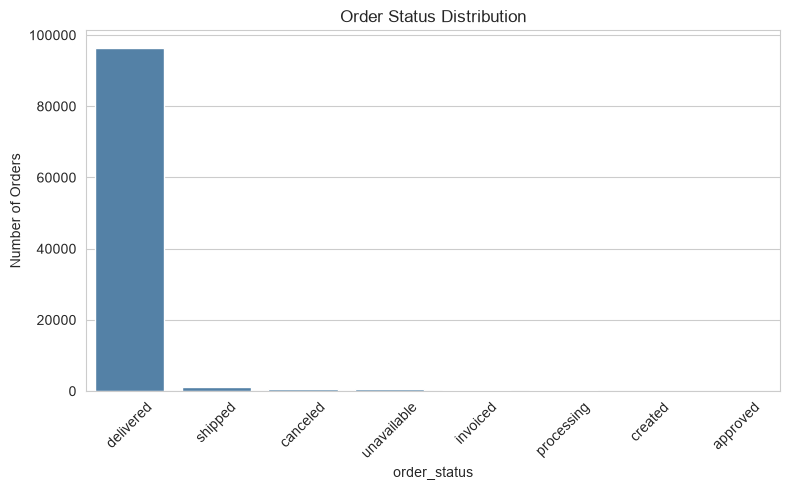

In [2]:
status_counts = df['order_status'].value_counts()
status_pct = (status_counts / len(df) * 100).round(2)
print(pd.DataFrame({'count': status_counts, 'pct': status_pct}))

plt.figure(figsize=(8, 5))
sns.barplot(x=status_counts.index, y=status_counts.values, color='steelblue')
plt.title('Order Status Distribution')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/figures/01_order_status.png', dpi=150)
plt.show()

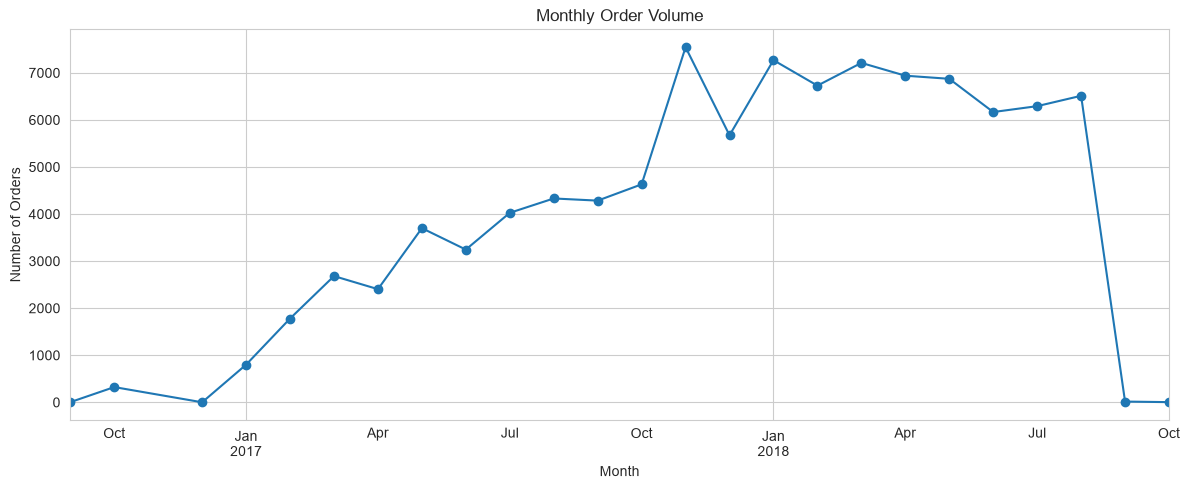

In [3]:
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')
monthly_orders = df.groupby('order_month').size()

plt.figure(figsize=(12, 5))
monthly_orders.plot(kind='line', marker='o')
plt.title('Monthly Order Volume')
plt.ylabel('Number of Orders')
plt.xlabel('Month')
plt.tight_layout()
plt.savefig('../reports/figures/02_monthly_orders.png', dpi=150)
plt.show()

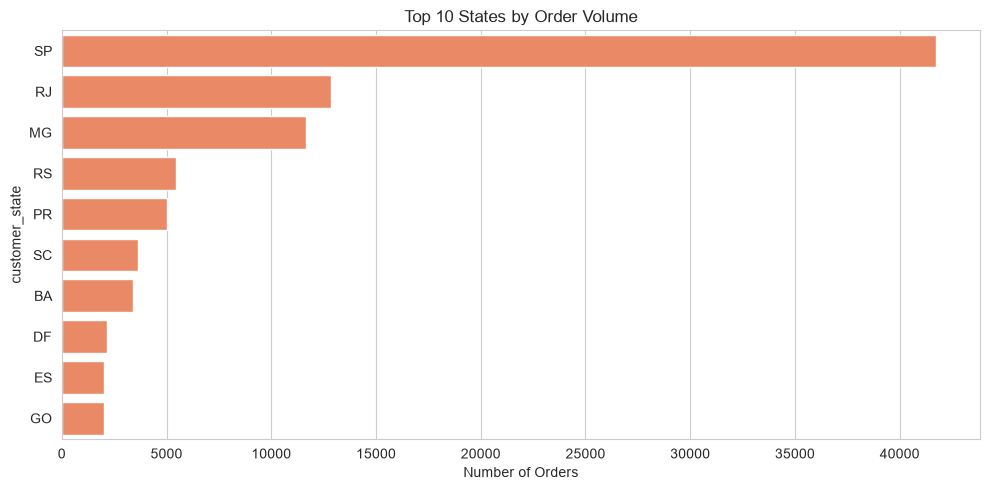

% orders từ state #1: 42.0%


In [4]:
state_counts = df['customer_state'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=state_counts.values, y=state_counts.index, color='coral')
plt.title('Top 10 States by Order Volume')
plt.xlabel('Number of Orders')
plt.tight_layout()
plt.savefig('../reports/figures/03_top_states.png', dpi=150)
plt.show()

print(f"% orders từ state #1: {state_counts.iloc[0] / len(df) * 100:.1f}%")

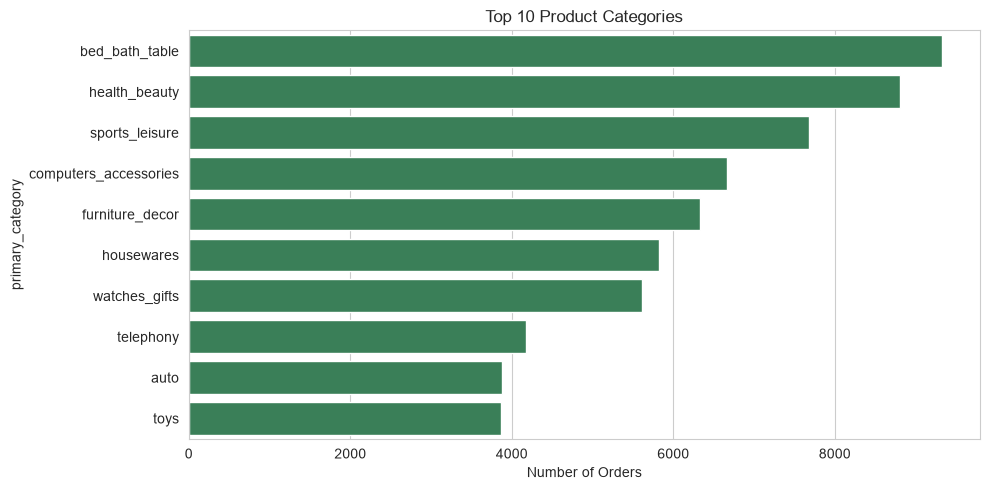

In [5]:
category_counts = df['primary_category'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=category_counts.values, y=category_counts.index, color='seagreen')
plt.title('Top 10 Product Categories')
plt.xlabel('Number of Orders')
plt.tight_layout()
plt.savefig('../reports/figures/04_top_categories.png', dpi=150)
plt.show()

% đơn giao trễ: 8.11%


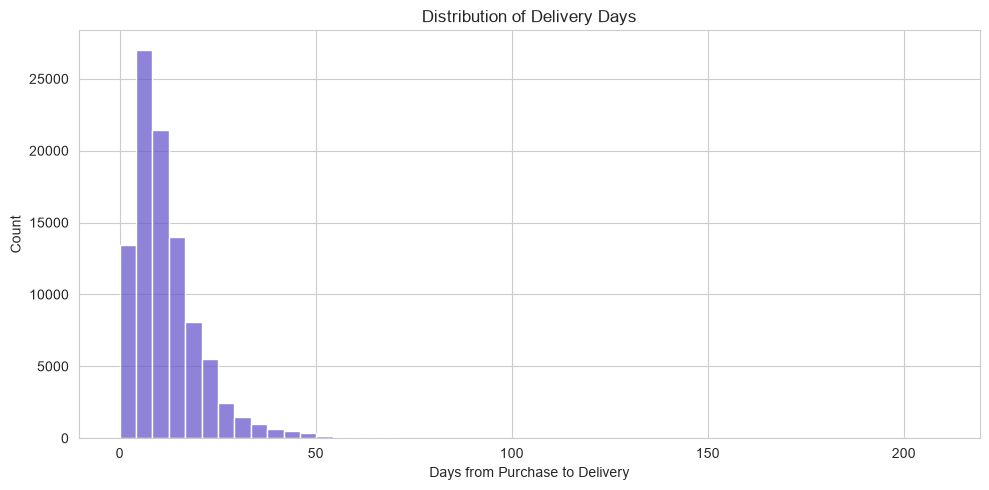

In [6]:
delivered = df[df['order_status'] == 'delivered']

late_pct = delivered['is_late_delivery'].mean() * 100
print(f"% đơn giao trễ: {late_pct:.2f}%")

plt.figure(figsize=(10, 5))
sns.histplot(delivered['delivery_days'].dropna(), bins=50, color='slateblue')
plt.title('Distribution of Delivery Days')
plt.xlabel('Days from Purchase to Delivery')
plt.tight_layout()
plt.savefig('../reports/figures/06_delivery_days.png', dpi=150)
plt.show()

Tổng số khách hàng (unique): 96,096
Khách mua >1 lần: 2,997 (3.12%)


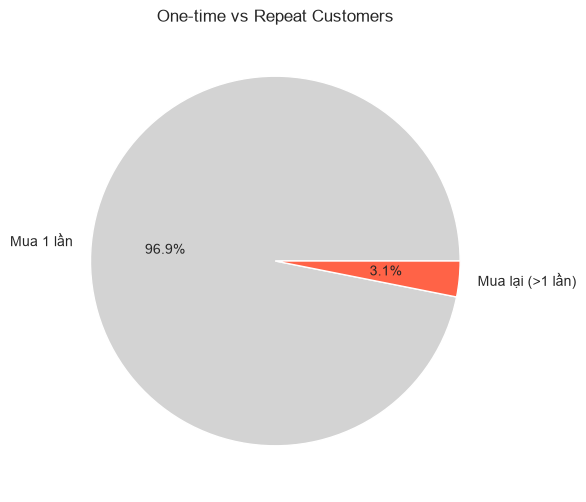

In [7]:
customer_orders = df.groupby('customer_unique_id')['order_id'].nunique()

total_customers = customer_orders.shape[0]
repeat_customers = (customer_orders > 1).sum()
repeat_pct = repeat_customers / total_customers * 100

print(f"Tổng số khách hàng (unique): {total_customers:,}")
print(f"Khách mua >1 lần: {repeat_customers:,} ({repeat_pct:.2f}%)")

plt.figure(figsize=(6, 6))
plt.pie(
    [total_customers - repeat_customers, repeat_customers],
    labels=['Mua 1 lần', 'Mua lại (>1 lần)'],
    autopct='%1.1f%%',
    colors=['lightgray', 'tomato']
)
plt.title('One-time vs Repeat Customers')
plt.savefig('../reports/figures/07_repeat_customers.png', dpi=150)
plt.show()